In [15]:
!pip install gymnasium ale-py autorom


In [9]:
!AutoROM --accept-license


AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	C:\Users\zaria\anaconda3\Lib\site-packages\AutoROM\roms

Existing ROMs will be overwritten.


C:\Users\zaria\anaconda3\Lib\site-packages\AutoROM\AutoROM.py:264: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [17]:
!pip install pygame


In [18]:
!pip install opencv-python


In [19]:
%pip install torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.


In [1]:
import gymnasium as gym
import ale_py
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import torch
import torch.nn as nn
import torch.optim as optim


In [2]:
gym.register_envs(ale_py)

# Training env — RAM only, no rendering (rendering during training slows things down a lot)
env = gym.make("ALE/Freeway-v5", obs_type="ram")
# ---------------------------
# RAM MAP (verified against real game data)
# ---------------------------
# byte 14       = chicken Y position
#                  6   = bottom (start)
#                  174 = top (just before crossing)
#                  resets to 6 when crossing completes (env reward=1.0 fires)
# bytes 43-52   = car X position for each of the 10 lanes
#                  byte 43 = lane 0 (bottom), byte 52 = lane 9 (top)
# chicken X     = always 48 (horizontally fixed)
#
# Lane boundaries (from live RAM probing):
#   lane 0: y  6-21   (byte 43)
#   lane 1: y 22-37   (byte 44)
#   lane 2: y 38-53   (byte 45)
#   lane 3: y 54-69   (byte 46)
#   lane 4: y 70-85   (byte 47)
#   lane 5: y 86-101  (byte 48)
#   lane 6: y102-117  (byte 49)
#   lane 7: y118-133  (byte 50)
#   lane 8: y134-149  (byte 51)
#   lane 9: y150+     (byte 52)

CHICKEN_X = 48
DANGER_GAP = 30  # gap (in X units) below which a car is considered dangerous
                 # verified: cars with gap < ~30 reliably block upward movement

def get_lane(chicken_y):
    """Return which of the 10 lanes (0=bottom, 9=top) the chicken is in."""
    return max(0, min(9, (chicken_y - 6) // 16))

def get_car_gap(obs, chicken_y):
    """
    Return the horizontal distance between the chicken and the nearest car
    in the chicken's current lane.
    
    Cars move horizontally across each lane, so we read the X position
    from the correct RAM byte for the lane and compare to chicken_x=48.
    """
    lane = get_lane(chicken_y)
    car_x = int(obs[43 + lane])
    return abs(car_x - CHICKEN_X)

def is_in_danger(obs, chicken_y):
    """True if a car is dangerously close in the current lane."""
    return get_car_gap(obs, chicken_y) < DANGER_GAP


In [3]:
# ---------------------------
# NEURAL NETWORK
# ---------------------------
class MLP(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )
    def forward(self, x):
        return self.net(x)

# Add 3 for danger, block_up, and block_down flags
# 1. Define the sizes first
input_size = 128 + 3
output_size = env.action_space.n # This equals 3

# 2. Now create the model using those sizes
model = MLP(input_size, output_size)

# 3. Finally, set up the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0003)


In [4]:

# Freeway specific constants
CHICKEN_X = 48
LANE_X_START_RAM = 108  # Corrected — verified by research paper (bytes 108-117)
DANGER_THRESHOLD = 30

def is_in_danger(obs, chicken_y):
    current_lane = max(0, min(9, (chicken_y - 6) // 16))
    car_x = obs[LANE_X_START_RAM + current_lane]
    return 1.0 if abs(int(car_x) - int(CHICKEN_X)) < DANGER_THRESHOLD else 0.0

def is_block_up(obs, chicken_y):
    current_lane = max(0, min(9, (chicken_y - 6) // 16))
    if current_lane >= 9: return 0.0
    lane_above_x = obs[LANE_X_START_RAM + current_lane + 1]
    return 1.0 if abs(int(lane_above_x) - int(CHICKEN_X)) < DANGER_THRESHOLD else 0.0

def is_block_down(obs, chicken_y):
    current_lane = max(0, min(9, (chicken_y - 6) // 16))
    if current_lane <= 0: return 0.0
    lane_below_x = obs[LANE_X_START_RAM + current_lane - 1]
    return 1.0 if abs(int(lane_below_x) - int(CHICKEN_X)) < DANGER_THRESHOLD else 0.0
    
def get_augmented_state(obs, chicken_y):
    # 1. Calculate situational flags
    # Assuming is_in_danger is already written similar to the ones above
    danger = is_in_danger(obs, chicken_y) 
    b_up = is_block_up(obs, chicken_y)
    b_down = is_block_down(obs, chicken_y)
    
    # 2. Normalize RAM (0-1)
    normalized_obs = obs.astype(np.float32) / 255.0
    
    # 3. Create the 3 extra features
    extra_features = np.array([float(danger), float(b_up), float(b_down)], dtype=np.float32)
    
    # 4. Combine into a 131-length vector (128 + 3)
    return np.concatenate([normalized_obs, extra_features])


In [6]:
# ---------------------------
# TRAINING 
# ---------------------------
RESET_TRAINING   = True  # True = start fresh, False = resume from checkpoint

episodes         = 501      # set to 1000-5000 for real training
gamma            = 0.99   # discount factor — makes agent care about future rewards
checkpoint_every = 1  # save every episode
YOUR_UP_ACTION_INDEX = 1
YOUR_DOWN_ACTION_INDEX = 2
HALF_EPISODE = 1400
START_Y = 6

episode_rewards = []
start_episode   = 0

collision_history = []   # total collisions per episode
entropy_history = []     # average entropy per episode

# ---------------------------
# CHECKPOINT LOADING
# ---------------------------
if not RESET_TRAINING:
    try:
        checkpoint = torch.load("checkpoint.pth", weights_only=False)
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        episode_rewards = checkpoint.get("episode_rewards", [])
        start_episode   = checkpoint["episode"] + 1
        print(f"Resuming from episode {start_episode}")
    except FileNotFoundError:
        print("No checkpoint found, starting fresh.")
else:
    print("RESET_TRAINING = True → Starting from scratch")

# ---------------------------
# TRAINING LOOP
# ---------------------------

# 1. Get the initial observation from the environment
obs, info = env.reset() 

test_state = get_augmented_state(obs, int(obs[14]))
# print(f"Model Input Shape: {test_state.shape}") # Should say (131,)               deubg

for episode in range(start_episode, episodes):
    entropy_coef = max(0.01, 0.05 * (0.999 ** episode))
    obs, _ = env.reset()

    prev_obs = None
    log_probs = []
    rewards   = []
    entropies = []
    done      = False
    episode_collisions  = 0
    episode_entropies   = []
    episode_crossings   = 0
    step_count          = 0
    max_y_this_episode  = int(obs[14])
    prev_y              = int(obs[14])
    frames_since_goal   = 999   # grace period counter — matches play cell
    prev_new_y          = int(obs[14])  # tracks post-step Y for delta
    was_collision_last_step = False   # for tracking collisions 
    frames_since_collision = 0
    frames_since_movement = 0

    while not done:
        step_count += 1
        block_up = False
        block_down = False
        reward = 0

        # 1. READ STATE
        chicken_y    = int(obs[14])
        current_lane = max(0, min(9, (chicken_y - 6) // 16))

        # 2. BUILD SMART INPUT — BEFORE stepping
        augmented_state = get_augmented_state(obs, chicken_y)
        state_input = torch.tensor(augmented_state, dtype=torch.float32).unsqueeze(0)
    
        # 3. AGENT DECIDES
        logits   = model(state_input)
        probs    = torch.softmax(logits, dim=1)
        dist     = torch.distributions.Categorical(probs)
        action   = dist.sample()
        log_prob = dist.log_prob(action)
        entropy  = dist.entropy()

        # 4. ENVIRONMENT STEP
        prev_y = chicken_y  # save PRE-step Y
        obs, env_reward, term, trunc, _ = env.step(action.item())
        done = term or trunc
        #env.render()        # ←              temporary 
        #time.sleep(0.02)    # ← slow it down to see what's happening

        # 5. POST-STEP MATH
        new_y         = int(obs[14])
        delta         = np.int16(new_y) - np.int16(prev_y)
        just_reset    = (delta < -50)
        current_lane  = max(0, min(9, (new_y - 6) // 16))
        car_x_current = int(obs[108 + current_lane])
        gap_current   = abs(car_x_current - CHICKEN_X)
        danger        = gap_current < DANGER_GAP

        lane_above_x = int(obs[43 + current_lane + 1]) if current_lane < 9 else None
        block_up     = lane_above_x is not None and abs(lane_above_x - CHICKEN_X) < DANGER_GAP

        lane_below_x = int(obs[43 + current_lane - 1]) if current_lane > 0 else None
        block_down   = lane_below_x is not None and abs(lane_below_x - CHICKEN_X) < DANGER_GAP

        # CROSSING
        if env_reward == 1.0:
            frames_since_goal = 0
        else:
            frames_since_goal += 1

        # COLLISION — byte 106 cooldown (perfect detection)
        cooldown      = int(obs[106])
        prev_cooldown = int(prev_obs[106]) if prev_obs is not None else 0
        collision_this_step = (cooldown > 0 and prev_cooldown == 0 and not just_reset)

        if collision_this_step:
            episode_collisions += 1
            frames_since_collision = 0
            reward -= 25.0
            #print(f"💥 COLLISION #{episode_collisions} | step={step_count}")       # for debug
        else:
            frames_since_collision += 1
            
        # 6. REWARD LOGIC
        # --- MOVEMENT ---
        if abs(delta) < 2:  # treat tiny jitter as no movement
            frames_since_movement += 1
        else:
            frames_since_movement = 0

        # --- BASE REWARD ---
        if env_reward == 1.0:
            episode_crossings += 1

            speed_bonus  = max(0, 500 - step_count) * 0.02
            reward = 30.0 #+ speed_bonus
            reward -= 0.2 * episode_collisions

            max_y_this_episode = new_y
            step_count = 0
        elif delta > 0:
            reward = 0.5  # moving up

        elif delta < 0:
            reward = -0.5  # stronger penalty → no jitter spam

        else:
            reward = -0.2  # idle

        # --- PROGRESS BONUS (core signal) ---
        if new_y > max_y_this_episode:
            #progress_bonus = (new_y - max_y_this_episode) * 1.0
            #reward += progress_bonus
            max_y_this_episode = new_y

        # --- SAFE PROGRESS BONUS (anti-farming version) ---
        if frames_since_collision >= 100 :
            reward += 20
            #print("reward for not colliding")
            frames_since_collision = 0

        # --- IDLE PENALTY (continuous, can't dodge) ---
        if frames_since_movement >= 30:
            reward -= 0.05 * frames_since_movement
            #print("penalty for not moving")
        
        episode_entropies.append(entropy.item())
        log_probs.append(log_prob)
        rewards.append(reward)
        prev_obs = obs.copy()

    # ---------------------------
    # DISCOUNTED RETURNS
    # ---------------------------
    returns = []
    
    total_reward = sum(rewards)
    episode_rewards.append(total_reward)
    collision_history.append(episode_collisions)

    if len(episode_entropies) > 0:
        entropy_history.append(np.mean(episode_entropies))
    else:
        entropy_history.append(0.0)

    # safety check (optional but good)
    assert len(entropy_history) == len(episode_rewards)

    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    returns = torch.tensor(returns, dtype=torch.float32)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ---------------------------
    # BASELINE
    # ---------------------------
    baseline = float(np.mean(episode_rewards[-50:])) if len(episode_rewards) >= 50 else 0.0

    # ---------------------------
    # POLICY UPDATE
    # ---------------------------
    loss = torch.tensor(0.0, requires_grad=True)
    for lp, G_t, ent in zip(log_probs, returns, episode_entropies):
        advantage = G_t - baseline
        loss = loss + (-lp * advantage) + (-entropy_coef * ent)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    total_reward = sum(rewards)
    
    if episode % checkpoint_every == 0:
        print(f"Episode {episode:>5} | Reward: {total_reward:>8.2f} | Crossings: {episode_crossings} | Collisions: {episode_collisions}")
        torch.save({
            "episode":          episode,
            "model_state":      model.state_dict(),
            "optimizer_state":  optimizer.state_dict(),
            "episode_rewards":  episode_rewards,
            "collision_history": collision_history,
            "entropy_history":   entropy_history,
        }, "checkpoint.pth")
        print(f"  → Checkpoint saved at episode {episode}")

torch.save(model.state_dict(), "freeway_mlp.pth")
print("\nTraining complete. Model saved to freeway_mlp.pth")
env.close()


RESET_TRAINING = True → Starting from scratch
Episode     0 | Reward:    25.90 | Crossings: 1 | Collisions: 28
  → Checkpoint saved at episode 0
Episode     1 | Reward:     1.00 | Crossings: 0 | Collisions: 25
  → Checkpoint saved at episode 1
Episode     2 | Reward:    16.00 | Crossings: 0 | Collisions: 25
  → Checkpoint saved at episode 2
Episode     3 | Reward:    87.90 | Crossings: 0 | Collisions: 28
  → Checkpoint saved at episode 3
Episode     4 | Reward:    74.00 | Crossings: 0 | Collisions: 24
  → Checkpoint saved at episode 4
Episode     5 | Reward:   -24.10 | Crossings: 0 | Collisions: 31
  → Checkpoint saved at episode 5
Episode     6 | Reward:    74.60 | Crossings: 0 | Collisions: 28
  → Checkpoint saved at episode 6
Episode     7 | Reward:     9.20 | Crossings: 0 | Collisions: 33
  → Checkpoint saved at episode 7
Episode     8 | Reward:   -16.00 | Crossings: 0 | Collisions: 33
  → Checkpoint saved at episode 8
Episode     9 | Reward:    51.80 | Crossings: 0 | Collisions: 2

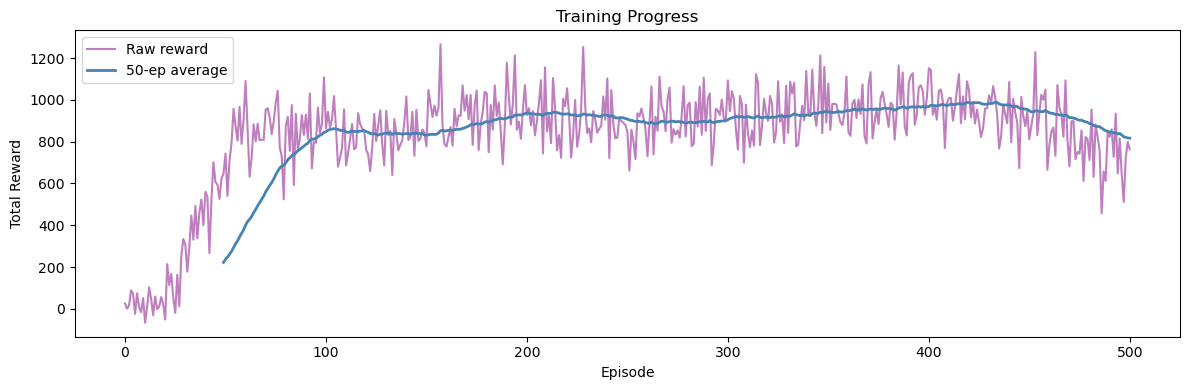

In [7]:
# ---------------------------
# TRAINING PROGRESS PLOT
# ---------------------------
# Raw reward per episode + 50-ep smoothed average.
# Look for:
#   - Upward trend = agent improving
#   - Plateau early = increase entropy_coef to keep exploring
#   - Reward spikes = crossing bonuses kicking in (good!)
# Assuming episode_rewards is your list of rewards per episode

# Load your checkpoint
checkpoint = torch.load("checkpoint.pth", weights_only=False)

# Extract the episode_rewards list
episode_rewards = checkpoint["episode_rewards"]

# Set your smoothing window
window = 50

# Plotting with your actual data
if len(episode_rewards) >= 2:
    current_window = min(window, len(episode_rewards))
    if len(episode_rewards) >= current_window:
        smoothed = np.convolve(episode_rewards, np.ones(current_window)/current_window, mode='valid')
        x_vals = list(range(current_window - 1, len(episode_rewards)))
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(episode_rewards, alpha=0.5, color='purple', linewidth=1.5, label='Raw reward')
        ax.plot(x_vals, smoothed, color='steelblue', linewidth=2, label=f'{current_window}-ep average')
    else:
        # Not enough data for smoothing; just plot raw rewards
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(episode_rewards, alpha=0.25, color='steelblue', label='Raw reward')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title('Training Progress')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Run more episodes to see a meaningful plot.")

In [8]:
print("entropy_history length:", len(entropy_history))
print("episodes:", len(episode_rewards))

entropy_history length: 501
episodes: 501


Episodes saved: 500
Rewards logged: 501
Total collisions: 18512
Entropy entries: 501


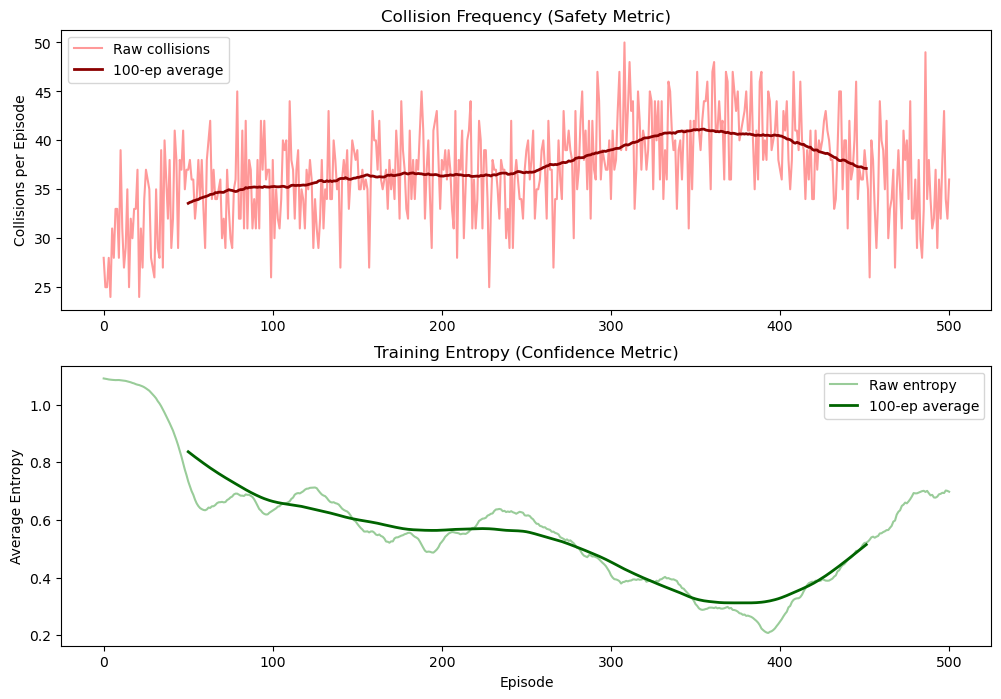

In [9]:
checkpoint = torch.load("checkpoint.pth", weights_only=False)

# Load histories first
episode_rewards   = checkpoint.get("episode_rewards", [])
collision_history = np.array(checkpoint.get("collision_history", []))
entropy_history   = np.array(checkpoint.get("entropy_history", []))

# Now print stats
print("Episodes saved:", checkpoint["episode"])
print("Rewards logged:", len(episode_rewards))
print("Total collisions:", np.sum(collision_history))
print("Entropy entries:", len(entropy_history))

# Plot
window = min(100, len(collision_history))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# COLLISIONS
if len(collision_history) > 0:
    ax1.plot(collision_history, alpha=0.4, color='red', label='Raw collisions')
    if len(collision_history) >= window:
        smoothed_col = np.convolve(
            collision_history,
            np.ones(window) / window,
            mode='valid'
        )
        x_smooth = np.arange(len(smoothed_col)) + window // 2
        ax1.plot(x_smooth, smoothed_col, color='darkred', linewidth=2,
                 label=f'{window}-ep average')
ax1.set_title("Collision Frequency (Safety Metric)")
ax1.set_ylabel("Collisions per Episode")
ax1.legend()

# ENTROPY
if len(entropy_history) > 0:
    ax2.plot(entropy_history, alpha=0.4, color='green', label='Raw entropy')
    if len(entropy_history) >= window:
        smoothed_ent = np.convolve(
            entropy_history,
            np.ones(window) / window,
            mode='valid'
        )
        x_smooth = np.arange(len(smoothed_ent)) + window // 2
        ax2.plot(x_smooth, smoothed_ent, color='darkgreen', linewidth=2,
                 label=f'{window}-ep average')
ax2.ticklabel_format(useOffset=False)
ax2.set_title("Training Entropy (Confidence Metric)")
ax2.set_ylabel("Average Entropy")
ax2.set_xlabel("Episode")
ax2.legend()

In [10]:
import numpy as np
import scipy.stats as stats
import torch

def evaluate_model(model, num_episodes=100):
    eval_env = gym.make("ALE/Freeway-v5", obs_type="ram")
    model.eval()

    eval_crossings  = []
    eval_collisions = []

    for _ in range(num_episodes):
        obs, _ = eval_env.reset()
        done                    = False
        episode_collisions      = 0
        episode_crossings       = 0
        step_count              = 0
        frames_since_goal       = 999
        was_collision_last_step = False
        prev_y                  = int(obs[14])

        while not done:
            step_count += 1
            chicken_y   = int(obs[14])

            state       = get_augmented_state(obs, chicken_y)
            state_input = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

            with torch.no_grad():
                action = torch.argmax(model(state_input), dim=1).item()

            prev_y = chicken_y
            obs, env_reward, term, trunc, _ = eval_env.step(action)
            done = term or trunc

            new_y         = int(obs[14])
            delta         = np.int16(new_y) - np.int16(prev_y)
            just_reset    = (delta < -50)
            current_lane  = max(0, min(9, (new_y - 6) // 16))
            car_x         = int(obs[43 + current_lane])
            danger        = abs(car_x - CHICKEN_X) < DANGER_GAP

            if env_reward == 1.0:
                episode_crossings += 1
                frames_since_goal  = 0
                step_count         = 0
            else:
                frames_since_goal += 1

            is_collision = (
                step_count > 1
                and not just_reset
                and frames_since_goal >= 8
                and action == 1
                and delta == 0
                and danger
            )

            if is_collision and not was_collision_last_step:
                episode_collisions += 1

            was_collision_last_step = is_collision if danger else False

        eval_crossings.append(episode_crossings)
        eval_collisions.append(episode_collisions)

    eval_env.close()
    return eval_crossings, eval_collisions
print("ran")

ran


In [ ]:

def confidence_interval(data, name, confidence=0.95):
    n      = len(data)
    mean   = np.mean(data)
    sem    = stats.sem(data)
    margin = sem * stats.t.ppf((1 + confidence) / 2, n - 1)
    print(f"{name}: {mean:.2f} ± {margin:.2f}  [{mean-margin:.2f}, {mean+margin:.2f}]")


# Load model
model.load_state_dict(torch.load("freeway_mlp.pth", weights_only=False))
model.eval()
print("Model loaded.")

# Run evaluation
print("Evaluating episodes...")
eval_crossings, eval_collisions = evaluate_model(model, num_episodes=100)

# Print confidence intervals
print("\n=== 95% Confidence Intervals ===")
confidence_interval(eval_crossings,  "Crossings per episode")
confidence_interval(eval_collisions, "Collisions per episode")

Model loaded.
Evaluating episodes...


In [ ]:
# ---------------------------
# PLAY LOOP
# ---------------------------
env_vis = gym.make("ALE/Freeway-v5", render_mode="human")
env_ram = gym.make("ALE/Freeway-v5", obs_type="ram")

obs_vis, _ = env_vis.reset(seed=42)
obs_ram, _ = env_ram.reset(seed=42)

checkpoint = torch.load("checkpoint.pth", weights_only=False)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print("AI is starting... Press 'q' in the window to stop.")

# Define action IDs
UP_ACTION    = 1
DOWN_ACTION  = 2
NOOP_ACTION  = 0

step_count           = 0
total_collision_count = 0
total_crossings      = 0
last_y               = int(obs_ram[14])
last_action          = 0
was_collision_last_step = False
frames_since_goal    = 999  # start high so no blocking at beginning
action               = NOOP_ACTION  # initialize before first step

while True:
    step_count += 1

    # 1. Read current state BEFORE stepping
    current_y = int(obs_ram[14])

    # 2. Build model input
    augmented_obs = get_augmented_state(obs_ram, current_y)
    ram_input = torch.tensor(augmented_obs, dtype=torch.float32).unsqueeze(0)

    # 3. Model prediction
    with torch.no_grad():
        logits = model(ram_input)
        action = torch.argmax(logits, dim=1).item()

    # 4. Step BOTH environments
    obs_vis, env_r1, term1, trunc1, _ = env_vis.step(action)
    obs_ram, _,      term2, trunc2, _ = env_ram.step(action)

    # 5. Post-step calculations
    new_y = int(obs_ram[14])
    delta_y = np.int16(new_y) - np.int16(current_y)  # current_y is pre-step, new_y is post-step
    just_reset = (delta_y < -50)

    # Crossing detection — most reliable signal
    reached_goal_reset = (env_r1 == 1.0)
    if reached_goal_reset:
        total_crossings += 1
        frames_since_goal = 0
        print(f" Crossing #{total_crossings} at step {step_count}!")
    else:
        frames_since_goal += 1
    # After calculating delta_y
    just_reset = (delta_y < -50)  # huge negative = crossing reset
    
    # debug
    # print(f"DEBUG | step={step_count} | delta_y={delta_y} | just_reset={just_reset} | reached_goal={reached_goal_reset} | frames_since_goal={frames_since_goal} | action={action}")
    
    # Collision detection  
    collision_this_step = (
        step_count > 1
        and not just_reset
        and frames_since_goal >= 8
        and delta == 0          # movement blocked
    )

    if collision_this_step and not was_collision_last_step:
        episode_collisions += 1
        # print("collision")

    # Collision ends when chicken moves again
    if delta != 0:
        was_collision_last_step = False
    elif collision_this_step:
        was_collision_last_step = True
    # print(f"💥 COLLISION #{total_collision_count} | step={step_count} | ΔY={delta_y}")
    

    # 7. Render
    frame_bgr = cv2.cvtColor(obs_vis.copy(), cv2.COLOR_RGB2BGR)

    cv2.putText(frame_bgr, f"Crossings: {total_crossings}",
                (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    cv2.putText(frame_bgr, f"Step: {step_count}",
                (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    if collision_this_step:
        cv2.putText(frame_bgr, "HIT!", (200, 100),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3)

    cv2.imshow("Freeway AI", frame_bgr)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    # 8. Reset if episode ends
    if term1 or trunc1 or term2 or trunc2:
        obs_vis, _ = env_vis.reset(seed=42)
        obs_ram, _ = env_ram.reset(seed=42)
        last_y                  = int(obs_ram[14])
        last_action             = 0
        was_collision_last_step = False
        frames_since_goal       = 999
        continue

    # 9. Update state
    last_y                  = current_y
    last_action             = action
    was_collision_last_step = collision_this_step

# Cleanup
env_vis.close()
env_ram.close()
cv2.destroyAllWindows()
print(f"\nFinal: {total_crossings} crossings | {total_collision_count} collisions | {step_count} steps")

AI is starting... Press 'q' in the window to stop.
 Crossing #1 at step 43!
